In [ ]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'air-quality-data-in-india' dataset.
Path to dataset files: /kaggle/input/air-quality-data-in-india


In [ ]:
print(os.listdir(path))

['stations.csv', 'station_hour.csv', 'city_day.csv', 'city_hour.csv', 'station_day.csv']


In [ ]:
city_day = pd.read_csv('/kaggle/input/air-quality-data-in-india/city_day.csv')
city_hour = pd.read_csv('/kaggle/input/air-quality-data-in-india/city_hour.csv')
station_day = pd.read_csv('/kaggle/input/air-quality-data-in-india/station_day.csv')
station_hour = pd.read_csv('/kaggle/input/air-quality-data-in-india/station_hour.csv')
stations = pd.read_csv('/kaggle/input/air-quality-data-in-india/stations.csv')

print("Data loaded successfully!")
print(f"\nDataset Shapes:")
print(f"city_day: {city_day.shape}")
print(f"city_hour: {city_hour.shape}")
print(f"station_day: {station_day.shape}")
print(f"station_hour: {station_hour.shape}")
print(f"stations: {stations.shape}")


/tmp/ipython-input-2758868556.py:4: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  station_hour = pd.read_csv('/kaggle/input/air-quality-data-in-india/station_hour.csv')


Data loaded successfully!

Dataset Shapes:
city_day: (29531, 16)
city_hour: (707875, 16)
station_day: (108035, 16)
station_hour: (2589083, 16)
stations: (230, 5)


In [ ]:
print("=" * 50)
print("CITY_DAY DATASET")
print("=" * 50)
print("\nFirst few rows:")
print(city_day.head())
print("\nData Info:")
print(city_day.info())
print("\nBasic Statistics:")
print(city_day.describe())
print("\nMissing Values:")
print(city_day.isnull().sum())

CITY_DAY DATASET

First few rows:
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  D

In [ ]:
df = city_day.copy()

In [ ]:
# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

# Check unique values in categorical columns
print("Unique Cities:", df['City'].nunique())
print("Unique AQI Buckets:", df['AQI_Bucket'].unique())

print("\nPreprocessing completed!")
print(f"Dataset shape after feature engineering: {df.shape}")

Unique Cities: 26
Unique AQI Buckets: [nan 'Poor' 'Very Poor' 'Severe' 'Moderate' 'Satisfactory' 'Good']

Preprocessing completed!
Dataset shape after feature engineering: (29531, 21)


In [ ]:
# Calculate missing percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_pct.index,
    'Missing_Percentage': missing_pct.values
}).sort_values('Missing_Percentage', ascending=False)

print("Missing Value Analysis:")
print(missing_df[missing_df['Missing_Percentage'] > 0])

Missing Value Analysis:
        Column  Missing_Percentage
13      Xylene           61.322001
3         PM10           37.723071
7          NH3           34.973418
12     Toluene           27.229014
11     Benzene           19.041008
14         AQI           15.851139
15  AQI_Bucket           15.851139
2        PM2.5           15.570079
6          NOx           14.171549
10          O3           13.619586
9          SO2           13.050692
5          NO2           12.139785
4           NO           12.129626
8           CO            6.972334


/tmp/ipython-input-3889018579.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df_plot, x='Missing_Percentage', y='Column', palette='viridis')


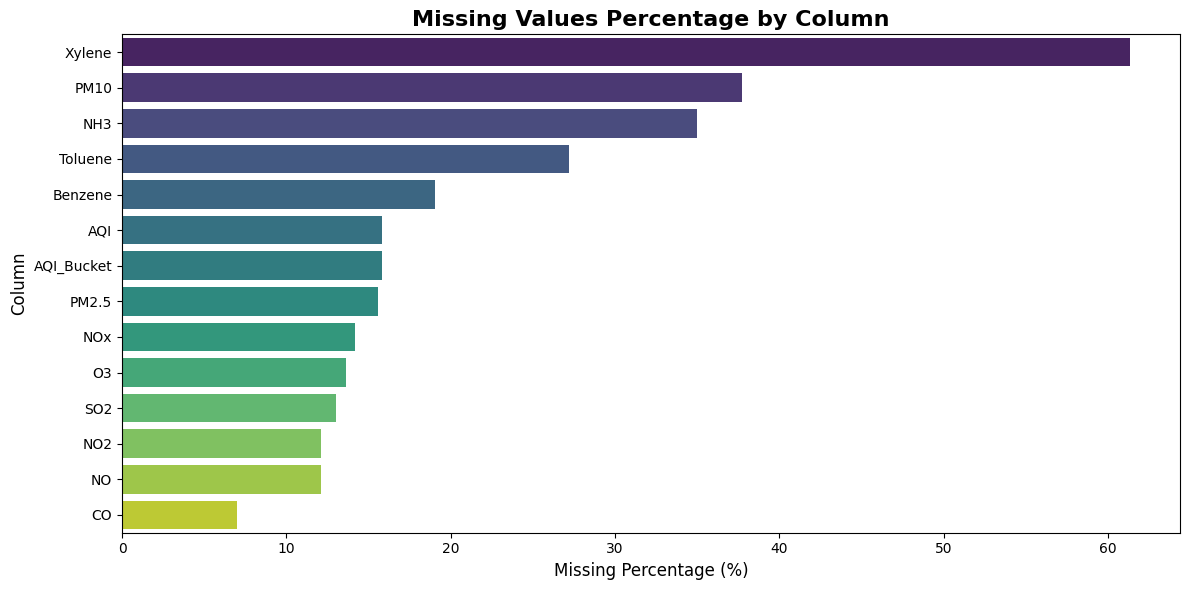

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
missing_df_plot = missing_df[missing_df['Missing_Percentage'] > 0]
sns.barplot(data=missing_df_plot, x='Missing_Percentage', y='Column', palette='viridis')
plt.title('Missing Values Percentage by Column', fontsize=16, fontweight='bold')
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.ylabel('Column', fontsize=12)
plt.tight_layout()
plt.show()


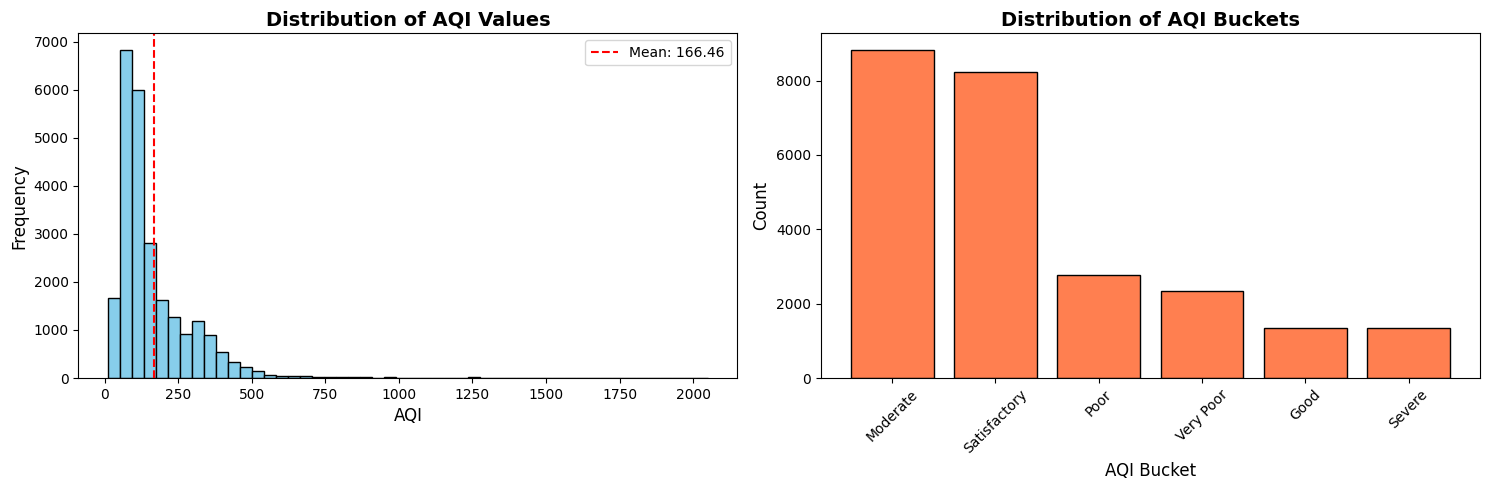


AQI Statistics:
Mean AQI: 166.46
Median AQI: 118.00
Min AQI: 13.00
Max AQI: 2049.00


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# AQI distribution
axes[0].hist(df['AQI'].dropna(), bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of AQI Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AQI', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(df['AQI'].mean(), color='red', linestyle='--', label=f'Mean: {df["AQI"].mean():.2f}')
axes[0].legend()

# AQI Bucket distribution
aqi_bucket_counts = df['AQI_Bucket'].value_counts()
axes[1].bar(aqi_bucket_counts.index, aqi_bucket_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Distribution of AQI Buckets', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AQI Bucket', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(f"\nAQI Statistics:")
print(f"Mean AQI: {df['AQI'].mean():.2f}")
print(f"Median AQI: {df['AQI'].median():.2f}")
print(f"Min AQI: {df['AQI'].min():.2f}")
print(f"Max AQI: {df['AQI'].max():.2f}")

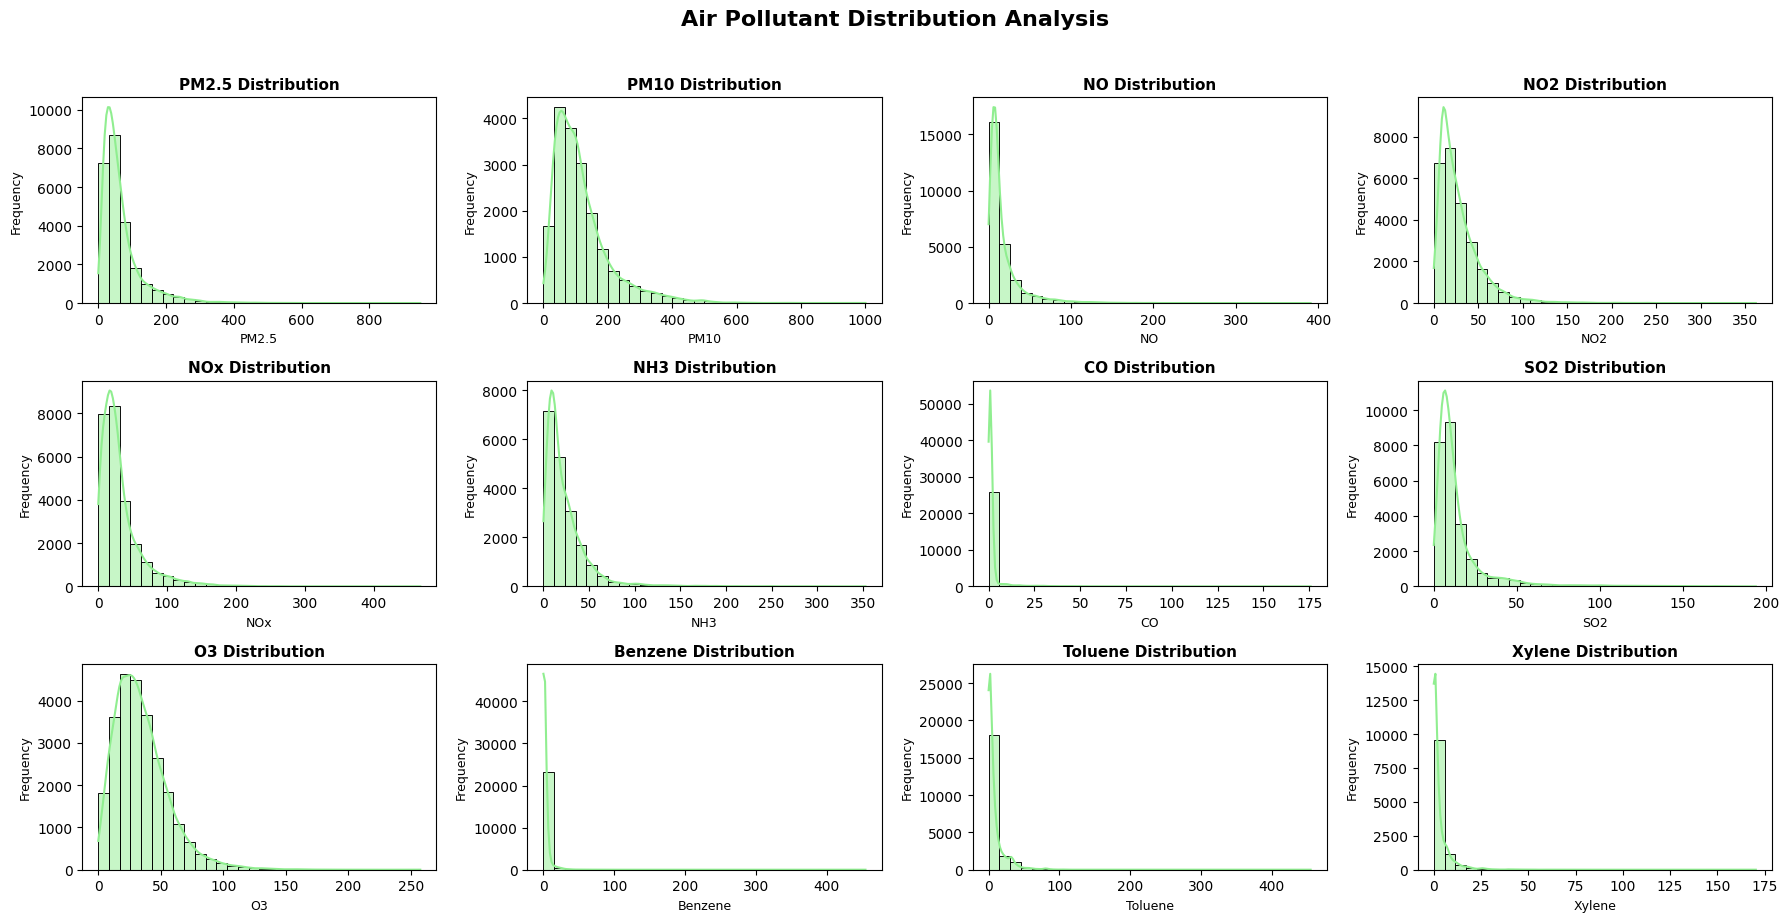

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define pollutants
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

# Keep only pollutants present in the dataset with enough non-missing values
available_pollutants = [p for p in pollutants if p in df.columns and df[p].notna().sum() > 100]

# Determine subplot grid size automatically
n = len(available_pollutants)
cols = 4
rows = (n + cols - 1) // cols  # automatic number of rows

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flatten()

# Plot histograms for each pollutant
for idx, pollutant in enumerate(available_pollutants):
    sns.histplot(df[pollutant].dropna(), bins=30, kde=True, color='lightgreen', ax=axes[idx])
    axes[idx].set_title(f'{pollutant} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(pollutant, fontsize=9)
    axes[idx].set_ylabel('Frequency', fontsize=9)

# Hide unused subplots
for idx in range(n, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Air Pollutant Distribution Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


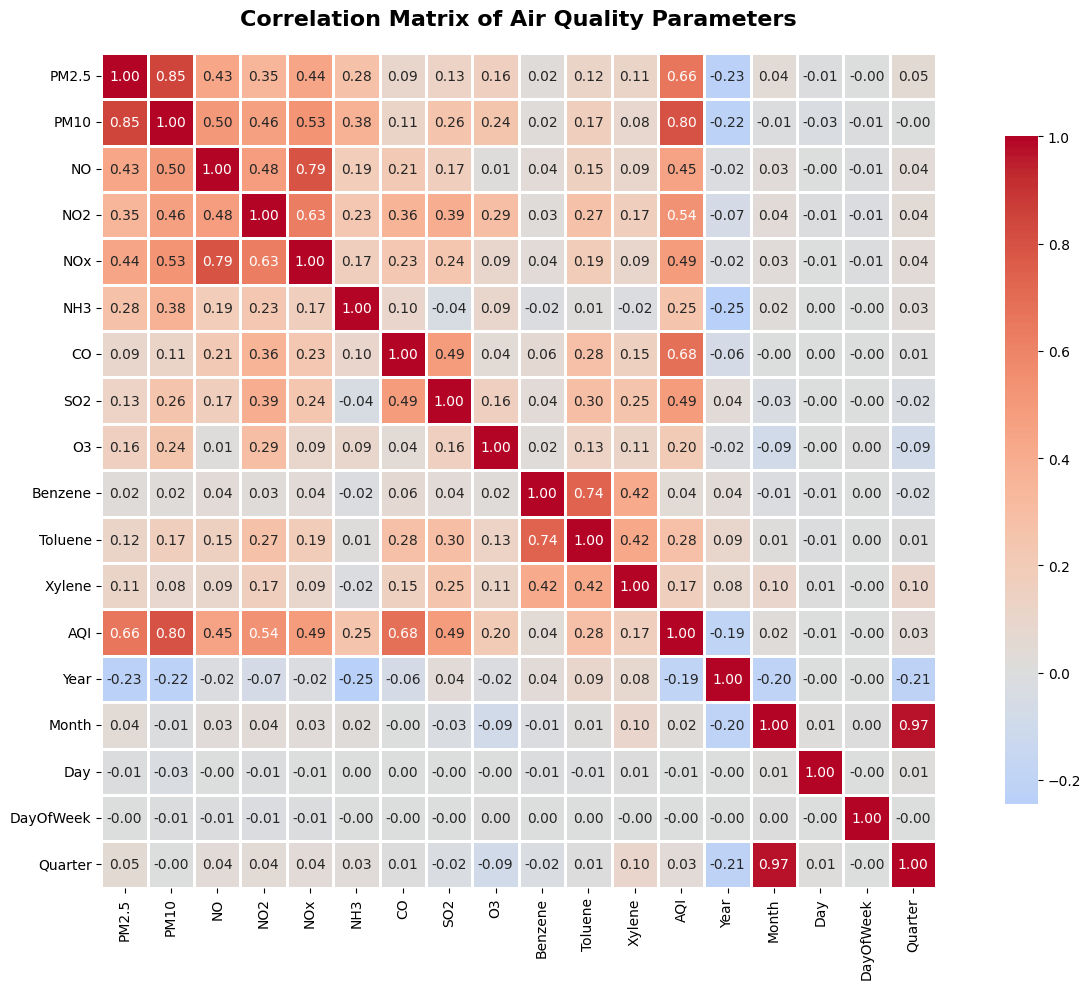


Correlation with AQI:
PM10       0.803313
CO         0.683346
PM2.5      0.659181
NO2        0.537071
SO2        0.490586
NOx        0.486450
NO         0.452191
Toluene    0.279992
NH3        0.252019
O3         0.198991
Name: AQI, dtype: float64


In [ ]:
# Select numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Air Quality Parameters', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show strong correlations with AQI
if 'AQI' in correlation_matrix.columns:
    aqi_corr = correlation_matrix['AQI'].sort_values(ascending=False)
    print("\nCorrelation with AQI:")
    print(aqi_corr[1:11])

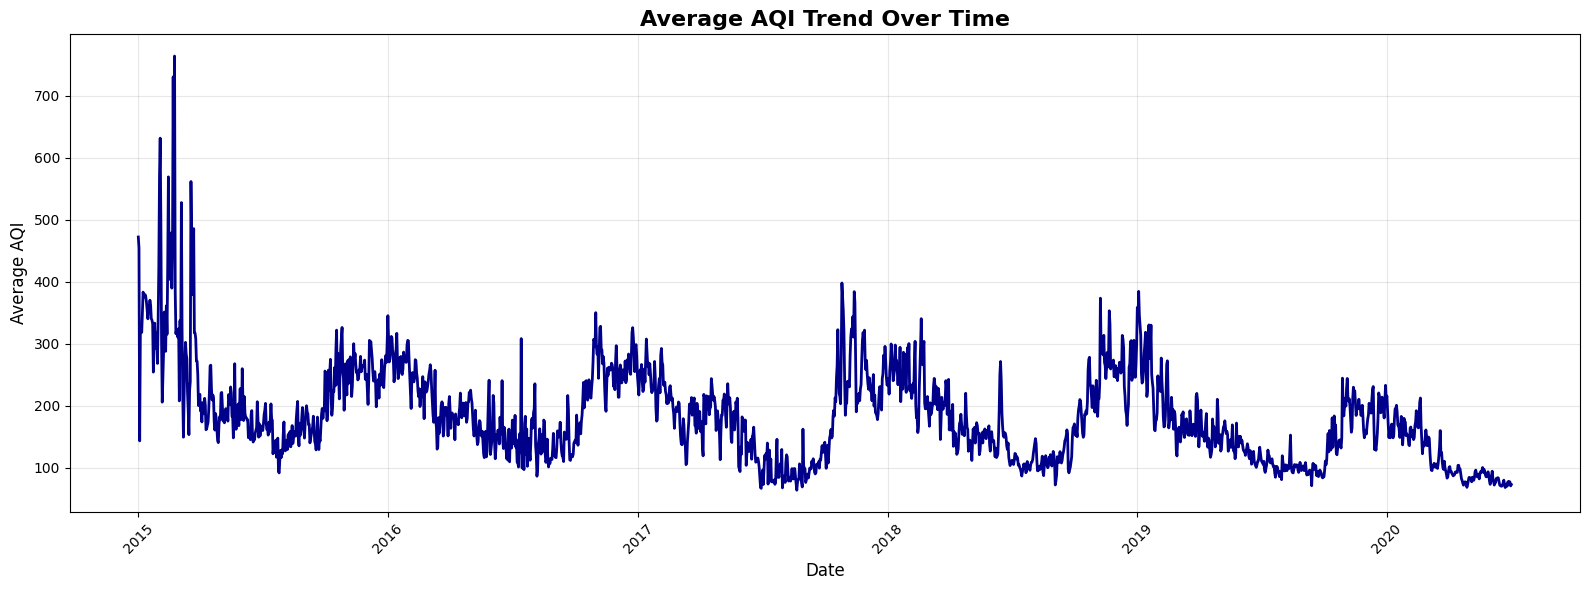

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Group by Date and calculate the mean AQI
df_time = df.groupby('Date', as_index=False)['AQI'].mean().sort_values('Date')

# Plot AQI trend
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_time, x='Date', y='AQI', color='darkblue', linewidth=2.0)
plt.title('Average AQI Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


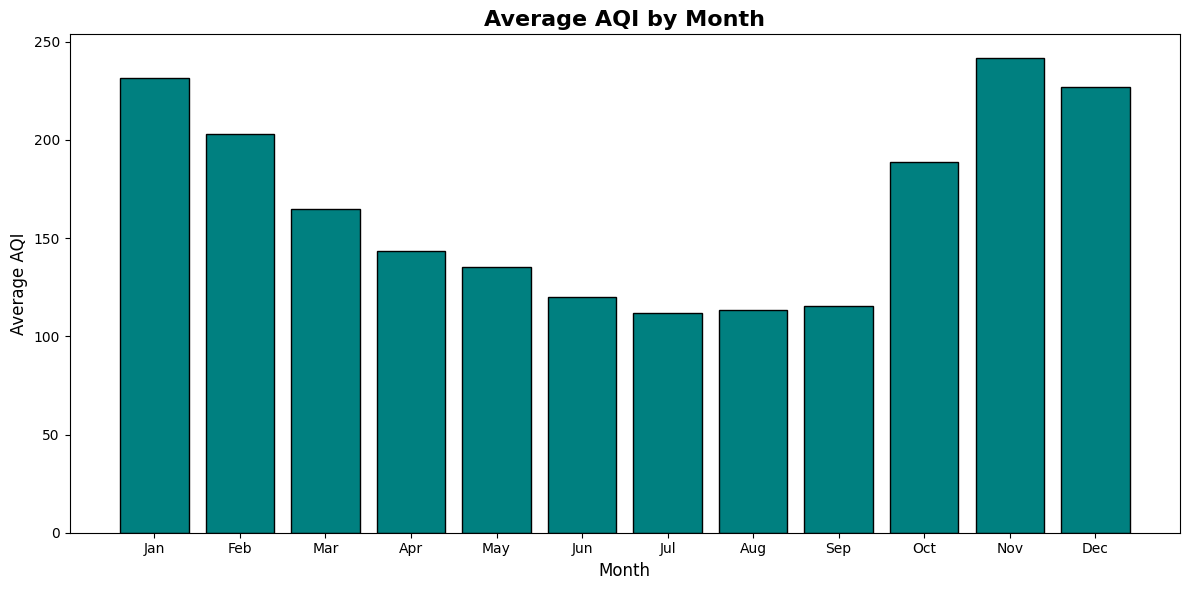

In [ ]:
# Monthly average AQI
monthly_aqi = df.groupby('Month')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(monthly_aqi['Month'], monthly_aqi['AQI'], color='teal', edgecolor='black')
plt.title('Average AQI by Month', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

/tmp/ipython-input-1708662829.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


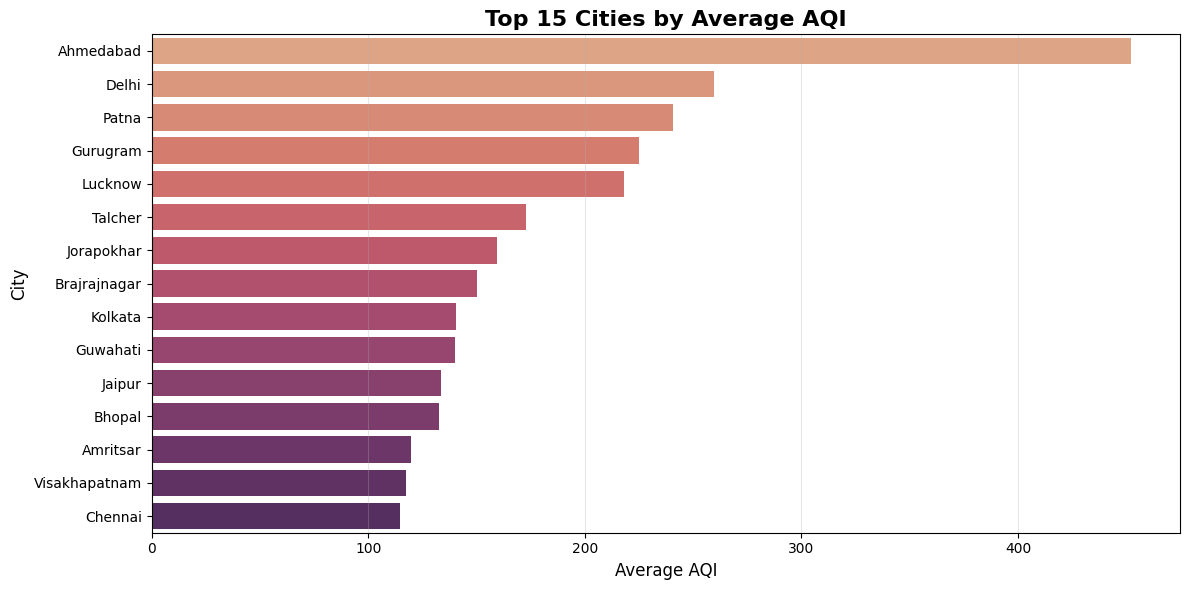

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Top 15 cities by average AQI
city_aqi = (
    df.groupby('City', as_index=False)['AQI']
      .mean()
      .sort_values(by='AQI', ascending=False)
      .head(15)
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=city_aqi,
    x='AQI',
    y='City',
    palette='flare'
)

plt.title('Top 15 Cities by Average AQI', fontsize=16, fontweight='bold')
plt.xlabel('Average AQI', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()




/tmp/ipython-input-651753654.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


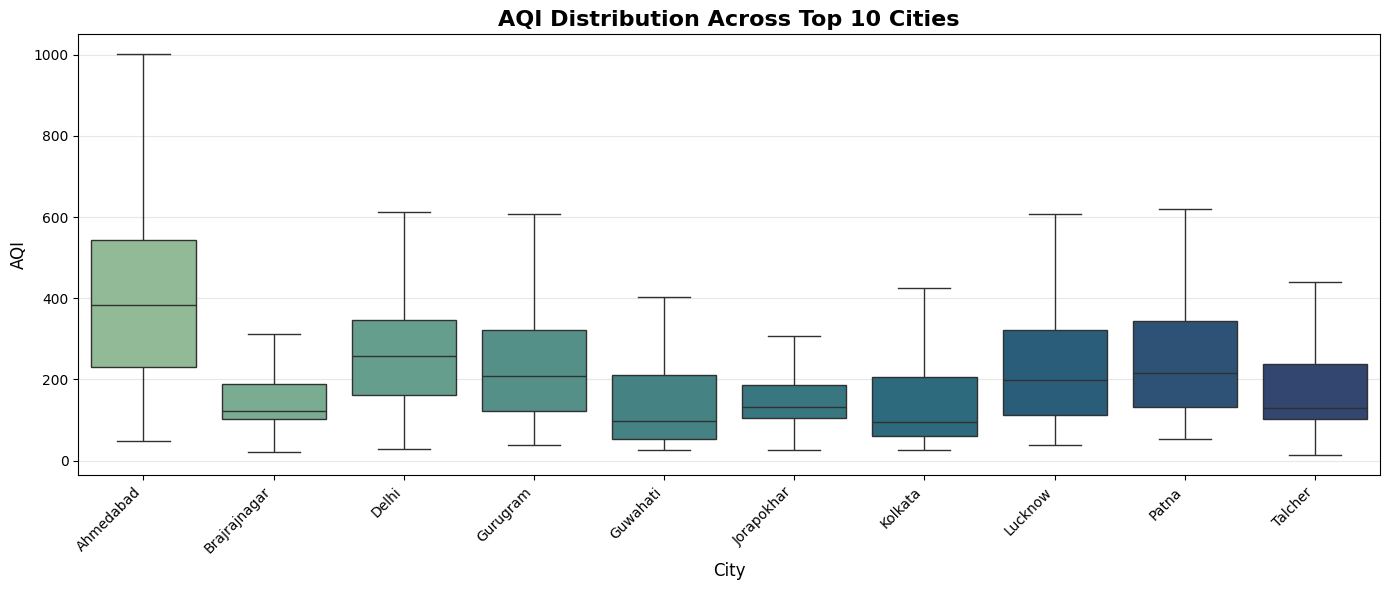

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Select top 10 cities based on average AQI
top_cities = (
    df.groupby('City')['AQI']
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .index
)

# Filter data for those cities
df_top_cities = df[df['City'].isin(top_cities)]

# Plot AQI distribution (boxplot)
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top_cities,
    x='City',
    y='AQI',
    palette='crest',
    showfliers=False  # hides extreme outliers for cleaner plot
)

plt.title('AQI Distribution Across Top 10 Cities', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('AQI', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Ensure the 'Date' column is in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Extract month from the date
df['Month'] = df['Date'].dt.month

# Define a function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

# Apply the mapping
df['Season'] = df['Month'].apply(get_season)

# Display to confirm
df[['Date', 'Month', 'Season']].head()


,Date,Month,Season
0,2015-01-01,1,Winter
1,2015-01-02,1,Winter
2,2015-01-03,1,Winter
3,2015-01-04,1,Winter
4,2015-01-05,1,Winter


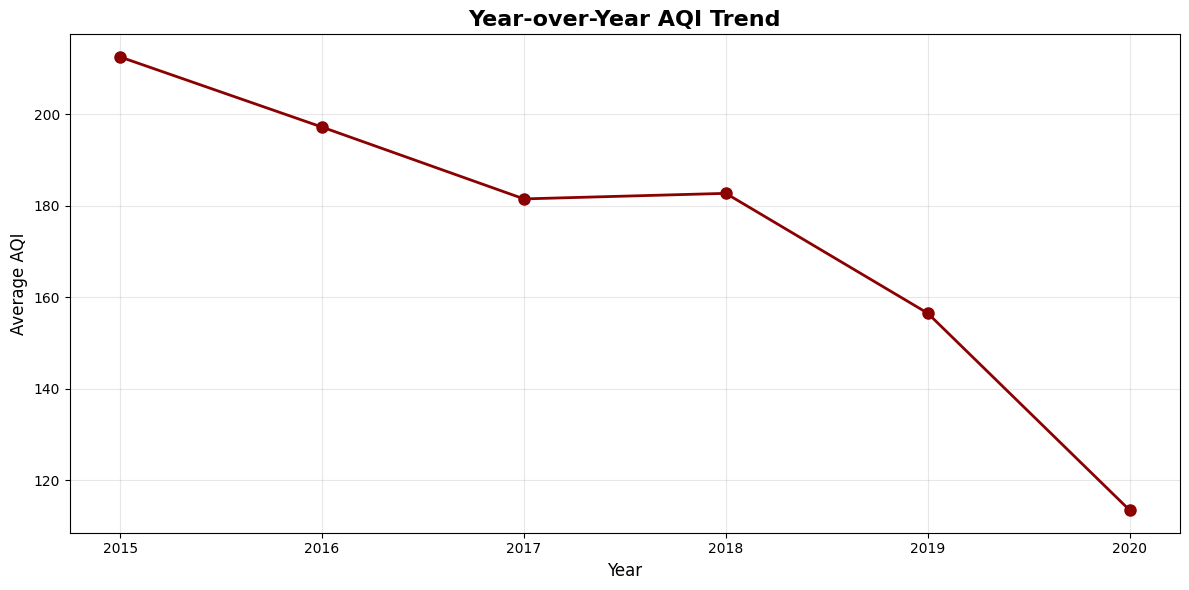


Yearly AQI Summary:
   Year         AQI
0  2015  212.463054
1  2016  197.150019
2  2017  181.472789
3  2018  182.684312
4  2019  156.518173
5  2020  113.520697


In [ ]:
yearly_aqi = df.groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(yearly_aqi['Year'], yearly_aqi['AQI'], marker='o', linewidth=2,
         markersize=8, color='darkred')
plt.title('Year-over-Year AQI Trend', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_aqi['Year'])
plt.tight_layout()
plt.show()

print("\nYearly AQI Summary:")
print(yearly_aqi)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Drop missing AQI values before sorting
df_valid = df.dropna(subset=['AQI'])

# Get top 20 most polluted days
top_polluted_days = (
    df_valid.nlargest(20, 'AQI')[['Date', 'City', 'AQI', 'PM2.5', 'PM10', 'AQI_Bucket']]
    .sort_values(by='AQI', ascending=False)
)

# Display the top polluted days in console
print("=" * 60)
print(" TOP 20 MOST POLLUTED DAYS IN INDIA")
print("=" * 60)
print(top_polluted_days.to_string(index=False))
print("=" * 60)

# Visualize the number of high-pollution days per city
plt.figure(figsize=(12, 6))
top_polluted_cities = (
    top_polluted_days['City']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'City', 'City': 'Count'})
)

sns.barplot(
    data=top_polluted_cities,
    x='City',
    y='Count',
    palette='Reds_r',
    edgecolor='black'
)

plt.title('Cities with Most High-Pollution Days (Top 20 AQI Records)', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of High-Pollution Days', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


 TOP 20 MOST POLLUTED DAYS IN INDIA
      Date      City    AQI  PM2.5   PM10 AQI_Bucket
2018-02-19 Ahmedabad 2049.0 242.66    NaN     Severe
2018-02-10 Ahmedabad 1917.0 185.77    NaN     Severe
2016-07-14 Ahmedabad 1842.0  38.13    NaN     Severe
2017-11-14 Ahmedabad 1747.0 207.19    NaN     Severe
2019-01-03 Ahmedabad 1719.0 131.50    NaN     Severe
2018-11-18 Ahmedabad 1672.0 127.46    NaN     Severe
2018-11-21 Ahmedabad 1646.0  86.52    NaN     Severe
2018-11-08 Ahmedabad 1630.0 205.21    NaN     Severe
2018-02-01 Ahmedabad 1613.0 189.12    NaN     Severe
2019-10-13 Ahmedabad 1595.0 194.36 335.86     Severe
2017-11-13 Ahmedabad 1577.0 119.17    NaN     Severe
2018-10-23 Ahmedabad 1561.0 129.98    NaN     Severe
2018-12-22 Ahmedabad 1558.0 111.75    NaN     Severe
2018-11-13 Ahmedabad 1548.0 133.13    NaN     Severe
2019-01-21 Ahmedabad 1537.0 149.26    NaN     Severe
2018-02-23 Ahmedabad 1526.0 138.40    NaN     Severe
2018-02-22 Ahmedabad 1483.0  91.66    NaN     Severe
2018-02-18

ValueError: Could not interpret value `City` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

🌫️  TOP 20 MOST POLLUTED DAYS IN INDIA
      Date      City    AQI  PM2.5   PM10 AQI_Bucket
2018-02-19 Ahmedabad 2049.0 242.66    NaN     Severe
2018-02-10 Ahmedabad 1917.0 185.77    NaN     Severe
2016-07-14 Ahmedabad 1842.0  38.13    NaN     Severe
2017-11-14 Ahmedabad 1747.0 207.19    NaN     Severe
2019-01-03 Ahmedabad 1719.0 131.50    NaN     Severe
2018-11-18 Ahmedabad 1672.0 127.46    NaN     Severe
2018-11-21 Ahmedabad 1646.0  86.52    NaN     Severe
2018-11-08 Ahmedabad 1630.0 205.21    NaN     Severe
2018-02-01 Ahmedabad 1613.0 189.12    NaN     Severe
2019-10-13 Ahmedabad 1595.0 194.36 335.86     Severe
2017-11-13 Ahmedabad 1577.0 119.17    NaN     Severe
2018-10-23 Ahmedabad 1561.0 129.98    NaN     Severe
2018-12-22 Ahmedabad 1558.0 111.75    NaN     Severe
2018-11-13 Ahmedabad 1548.0 133.13    NaN     Severe
2019-01-21 Ahmedabad 1537.0 149.26    NaN     Severe
2018-02-23 Ahmedabad 1526.0 138.40    NaN     Severe
2018-02-22 Ahmedabad 1483.0  91.66    NaN     Severe
2018-02

/tmp/ipython-input-1649861721.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_polluted_cities, x='City', y='Count', palette='Reds_r', edgecolor='black')


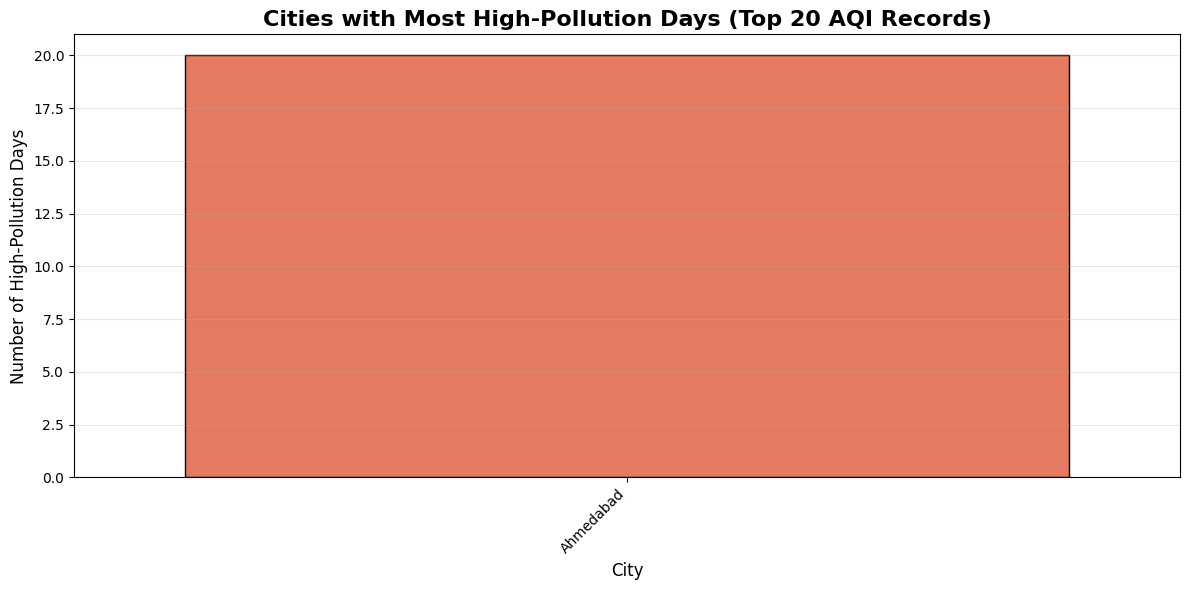

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct datatypes
df['AQI'] = pd.to_numeric(df.get('AQI'), errors='coerce')

# Drop missing AQI
df_valid = df.dropna(subset=['AQI'])

# Select available columns safely
available_cols = [col for col in ['Date', 'City', 'AQI', 'PM2.5', 'PM10', 'AQI_Bucket'] if col in df_valid.columns]

# Get top 20 most polluted days
top_polluted_days = df_valid.nlargest(20, 'AQI')[available_cols].sort_values(by='AQI', ascending=False)

# Print summary
print("=" * 60)
print("🌫️  TOP 20 MOST POLLUTED DAYS IN INDIA")
print("=" * 60)
print(top_polluted_days.to_string(index=False))
print("=" * 60)

# Visualization
plt.figure(figsize=(12, 6))
top_polluted_cities = top_polluted_days['City'].value_counts().reset_index()
top_polluted_cities.columns = ['City', 'Count']

sns.barplot(data=top_polluted_cities, x='City', y='Count', palette='Reds_r', edgecolor='black')
plt.title('Cities with Most High-Pollution Days (Top 20 AQI Records)', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of High-Pollution Days', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



  TOP 15 CITIES - COMPREHENSIVE AIR QUALITY STATISTICS
               AQI_mean  AQI_median  AQI_max  AQI_std  PM25_mean  PM10_mean
City                                                                       
Ahmedabad        452.12       384.5   2049.0   311.73      67.85     114.58
Delhi            259.49       257.0    716.0   119.54     117.20     232.81
Patna            240.78       215.0    619.0   122.34     123.50     126.75
Gurugram         225.12       208.0    891.0   119.94     117.10     191.50
Lucknow          217.97       198.0    707.0   116.96     109.71        NaN
Talcher          172.89       128.5    570.0   104.87      61.41     165.77
Jorapokhar       159.25       133.0    604.0    84.70      64.23     149.66
Brajrajnagar     150.28       122.0    355.0    70.37      64.06     124.22
Kolkata          140.57        94.0    475.0   104.49      64.36     115.63
Guwahati         140.11        98.0    956.0   112.76      63.69     116.60
Jaipur           133.68       12

/tmp/ipython-input-53473244.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


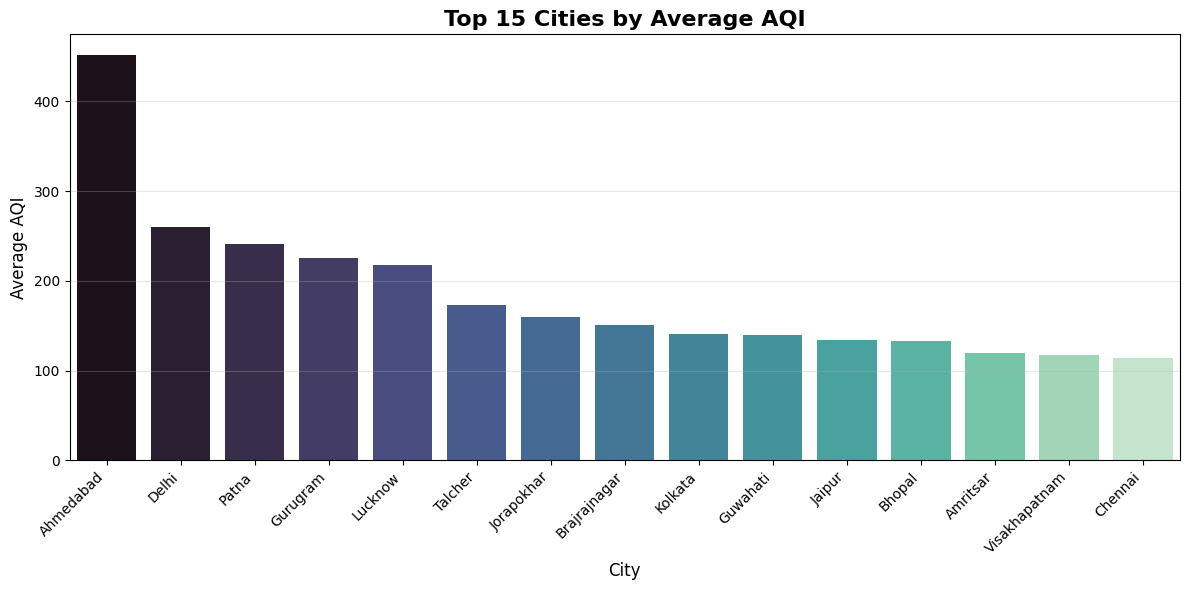

In [ ]:
c


In [ ]:
# Create comprehensive city rankings
city_stats = df.groupby('City').agg({
    'AQI': ['mean', 'median', 'max', 'std'],
    'PM2.5': 'mean',
    'PM10': 'mean'
}).round(2)

city_stats.columns = ['_'.join(col).strip() for col in city_stats.columns.values]
city_stats = city_stats.sort_values('AQI_mean', ascending=False).head(15)

print("\n" + "=" * 50)
print("TOP 15 CITIES - COMPREHENSIVE STATISTICS")
print("=" * 50)
print(city_stats)





TOP 15 CITIES - COMPREHENSIVE STATISTICS
               AQI_mean  AQI_median  AQI_max  AQI_std  PM2.5_mean  PM10_mean
City                                                                        
Ahmedabad        452.12       384.5   2049.0   311.73       67.85     114.58
Delhi            259.49       257.0    716.0   119.54      117.20     232.81
Patna            240.78       215.0    619.0   122.34      123.50     126.75
Gurugram         225.12       208.0    891.0   119.94      117.10     191.50
Lucknow          217.97       198.0    707.0   116.96      109.71        NaN
Talcher          172.89       128.5    570.0   104.87       61.41     165.77
Jorapokhar       159.25       133.0    604.0    84.70       64.23     149.66
Brajrajnagar     150.28       122.0    355.0    70.37       64.06     124.22
Kolkata          140.57        94.0    475.0   104.49       64.36     115.63
Guwahati         140.11        98.0    956.0   112.76       63.69     116.60
Jaipur           133.68       122.


LAG CORRELATION ANALYSIS
               AQI  AQI_lag1  AQI_lag7
AQI       1.000000  0.881282  0.717630
AQI_lag1  0.881282  1.000000  0.726556
AQI_lag7  0.717630  0.726556  1.000000


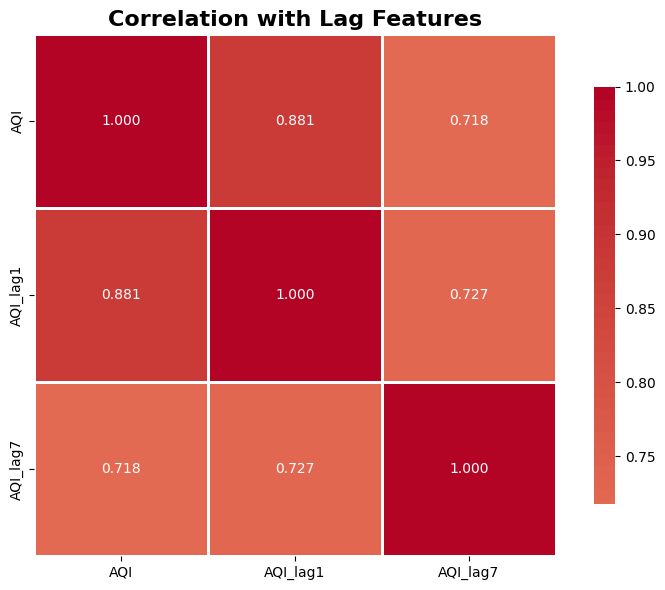

In [ ]:
# Create lag features for time series analysis
df_sorted = df.sort_values(['City', 'Date'])
df_sorted['AQI_lag1'] = df_sorted.groupby('City')['AQI'].shift(1)
df_sorted['AQI_lag7'] = df_sorted.groupby('City')['AQI'].shift(7)

# Check correlation
lag_corr = df_sorted[['AQI', 'AQI_lag1', 'AQI_lag7']].corr()

print("\n" + "=" * 50)
print("LAG CORRELATION ANALYSIS")
print("=" * 50)
print(lag_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(lag_corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=2, cbar_kws={"shrink": 0.8})
plt.title('Correlation with Lag Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

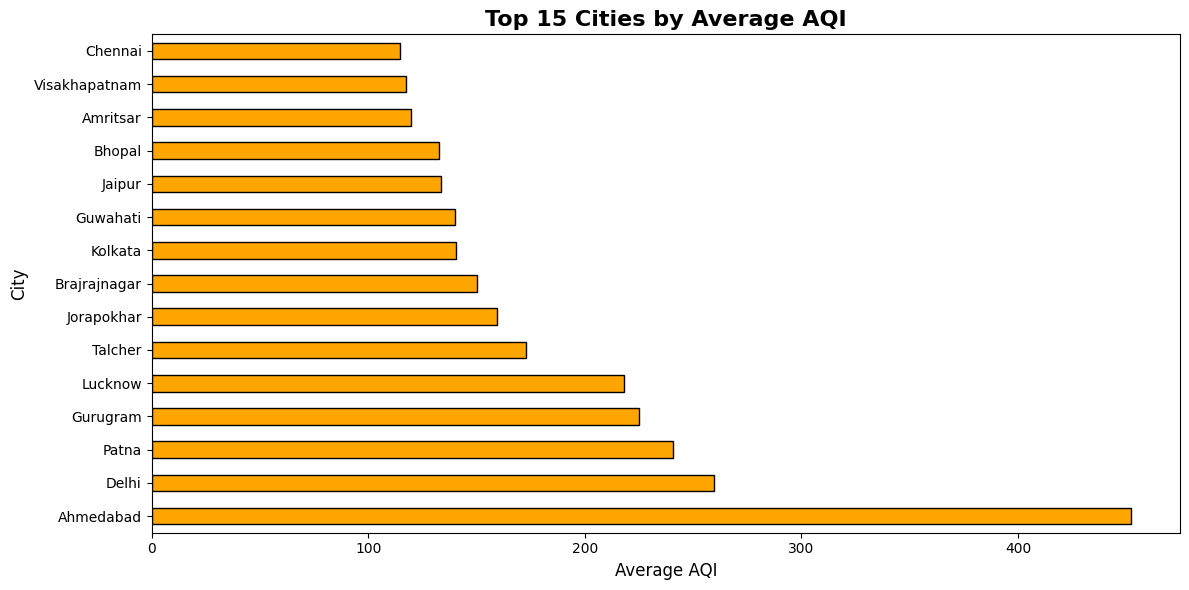

In [ ]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
city_aqi.plot(kind='barh', color='orange', edgecolor='black')
plt.title('Top 15 Cities by Average AQI', fontsize=16, fontweight='bold')
plt.xlabel('Average AQI', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.tight_layout()
plt.show()


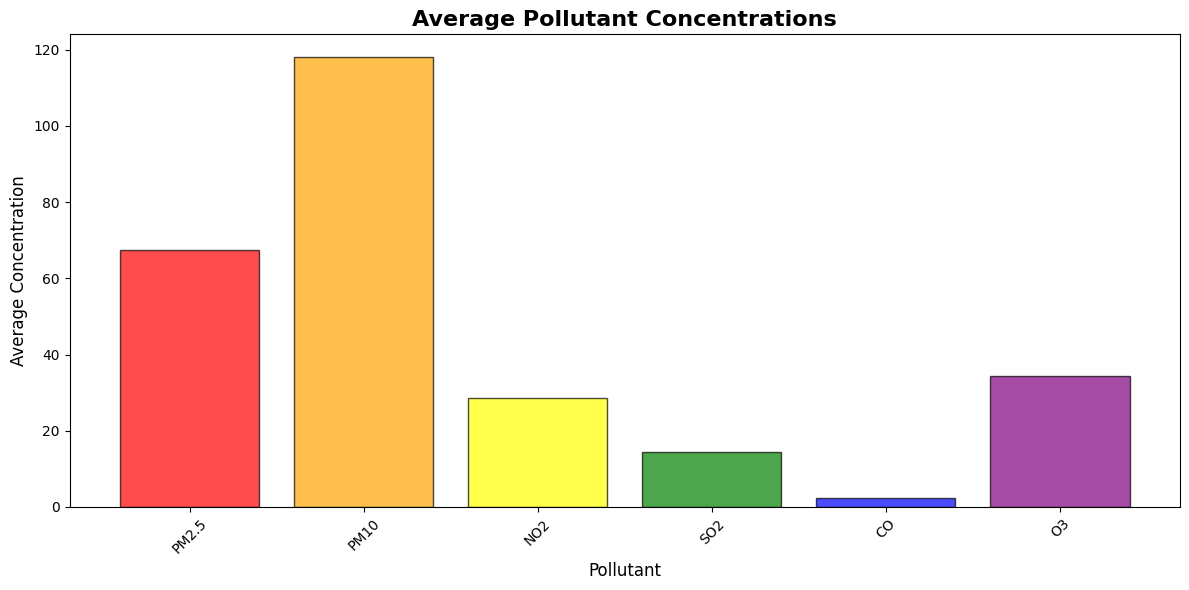

In [ ]:
pollutant_avgs = {}
for pollutant in ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']:
    if pollutant in df.columns:
        pollutant_avgs[pollutant] = df[pollutant].mean()

if pollutant_avgs:
    plt.figure(figsize=(12, 6))
    plt.bar(pollutant_avgs.keys(), pollutant_avgs.values(),
            color=['red', 'orange', 'yellow', 'green', 'blue', 'purple'],
            edgecolor='black', alpha=0.7)
    plt.title('Average Pollutant Concentrations', fontsize=16, fontweight='bold')
    plt.ylabel('Average Concentration', fontsize=12)
    plt.xlabel('Pollutant', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()